In [87]:
import json
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import joblib






with open("../repository/repository_signals.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [88]:
scaler = StandardScaler()

joblib.dump(kmeans, "../repository/kmeans_k6.pkl")
joblib.dump(scaler, "../repository/scaler.pkl")

['../repository/scaler.pkl']

In [5]:
df.shape, df.columns.tolist()

((279, 23),
 ['record_id',
  'post_id',
  'text',
  'source',
  'report_title',
  'url',
  'sports',
  'date',
  'week',
  'season_phase',
  'ingested_at',
  'sentiment',
  'sentiment_score',
  'emotional_affinity_score',
  'behavioral_pathway',
  'priority_signal',
  'confidence_score',
  'subreddit',
  'reddit_post_id',
  'reddit_comment_id',
  'content_type',
  'score',
  'search_query'])

In [6]:
df[["source", "sports", "behavioral_pathway", "sentiment", "priority_signal"]].head(10)

,source,sports,behavioral_pathway,sentiment,priority_signal
0,wasserman,[general],none,positive,none
1,wasserman,[WNBA],none,neutral,none
2,wasserman,[general],none,positive,none
3,deloitte,[general],none,positive,cross_sport_superfan
4,deloitte,[NWSL],purchase_intent,positive,none
5,deloitte,[general],none,neutral,none
6,bcg,[general],none,positive,none
7,bcg,"[WNBA, NWSL, WTA]",purchase_intent,positive,none
8,bcg,[WTA],none,positive,none
9,nielsen,[general],none,positive,none


In [12]:
df["priority_signal"].unique()

<StringArray>
[                'none', 'cross_sport_superfan',       'loyalty_stress',
      'identity_anchor',          'trust_split',    'conversion_moment']
Length: 6, dtype: str

In [23]:
mask_drop = (df["source"] == "reddit") & (df["sports"].apply(lambda x: x == ["general"]))
df_filtered = df[~mask_drop]
print(len(df))
print(len(df_filtered))

print((df["source"] == "reddit").sum())           # counts Trues
print((df_filtered["source"] == "reddit").sum())  # should be different



279
93
264
78


In [27]:
df_filtered[df_filtered["source"] == "reddit"]["sports"].value_counts()

sports
[WNBA]    48
[NWSL]    30
Name: count, dtype: int64

In [28]:
df_filtered["source"].value_counts()

source
reddit       78
wasserman     3
deloitte      3
bcg           3
nielsen       3
mckinsey      3
Name: count, dtype: int64

In [33]:
sentiment_map = {"negative": 0, "neutral": 1, "positive": 2}
df_filtered["sentiment"] = df["sentiment"].map(sentiment_map)
print(df_filtered["sentiment"])

0     2
1     1
2     2
3     2
4     2
     ..
88    2
89    2
90    2
91    2
92    2
Name: sentiment, Length: 93, dtype: int64


In [37]:
df_encoded["sentiment"] = df["sentiment"].map(sentiment_map)
df_encoded = pd.get_dummies(df_filtered, columns=["behavioral_pathway", "priority_signal"])

In [38]:
df_encoded.columns.tolist()

['record_id',
 'post_id',
 'text',
 'source',
 'report_title',
 'url',
 'sports',
 'date',
 'week',
 'season_phase',
 'ingested_at',
 'sentiment',
 'sentiment_score',
 'emotional_affinity_score',
 'confidence_score',
 'subreddit',
 'reddit_post_id',
 'reddit_comment_id',
 'content_type',
 'score',
 'search_query',
 'behavioral_pathway_churn_risk',
 'behavioral_pathway_community_influence',
 'behavioral_pathway_identity_attachment',
 'behavioral_pathway_none',
 'behavioral_pathway_purchase_intent',
 'priority_signal_cross_sport_superfan',
 'priority_signal_identity_anchor',
 'priority_signal_loyalty_stress',
 'priority_signal_none']

In [42]:

df_encoded.rename(columns={"sentiment": "sentiment_encoded"}, inplace=True)

In [41]:
# Compare original uniques vs what got encoded
original_bp = df_filtered["behavioral_pathway"].unique()
original_ps = df_filtered["priority_signal"].unique()

encoded_bp = [c.replace("behavioral_pathway_", "") for c in df_encoded.columns if c.startswith("behavioral_pathway_")]
encoded_ps = [c.replace("priority_signal_", "") for c in df_encoded.columns if c.startswith("priority_signal_")]

print(set(original_bp) - set(encoded_bp))  # should be empty
print(set(original_ps) - set(encoded_ps))  # should be empty

set()
set()


In [44]:
df_encoded["sentiment_encoded"].value_counts()

sentiment_encoded
2    69
0    17
1     7
Name: count, dtype: int64

In [45]:
feature_cols = [
    "sentiment_encoded",
    "sentiment_score",
    "emotional_affinity_score",
    "confidence_score",
] + [c for c in df_encoded.columns if c.startswith("behavioral_pathway_") or c.startswith("priority_signal_")]

df_encoded[feature_cols].head()

,sentiment_encoded,sentiment_score,emotional_affinity_score,confidence_score,behavioral_pathway_churn_risk,behavioral_pathway_community_influence,behavioral_pathway_identity_attachment,behavioral_pathway_none,behavioral_pathway_purchase_intent,priority_signal_cross_sport_superfan,priority_signal_identity_anchor,priority_signal_loyalty_stress,priority_signal_none
0,2,0.79,97,0.78,False,False,False,True,False,False,False,False,True
1,1,0.50,92,0.46,False,False,False,True,False,False,False,False,True
2,2,0.70,82,0.61,False,False,False,True,False,False,False,False,True
3,2,0.79,83,0.71,False,False,False,True,False,True,False,False,False
4,2,0.70,77,0.59,False,False,False,False,True,False,False,False,True


In [67]:
feature_cols = [
    "sentiment_score",
    "emotional_affinity_score",
    "confidence_score",
] 

In [68]:
X = df_encoded[feature_cols].copy()
X = X.astype(float)  # converts True/False to 1.0/0.0
print(X.shape)
X.describe()

(93, 3)


,sentiment_score,emotional_affinity_score,confidence_score
count,93.00000,93.000000,93.000000
mean,0.69914,73.935484,0.663011
std,0.26429,19.799433,0.176652
min,0.03000,28.000000,0.210000
25%,0.51000,59.000000,0.550000
50%,0.77000,82.000000,0.680000
75%,0.92000,91.000000,0.800000
max,1.00000,98.000000,0.960000


In [69]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
pd.DataFrame(X_scaled).describe().round(4)

,sentiment_score,emotional_affinity_score,confidence_score
count,93.0000,93.0000,93.0000
mean,0.0000,-0.0000,0.0000
std,1.0054,1.0054,1.0054
min,-2.5456,-2.3326,-2.5783
25%,-0.7195,-0.7584,-0.6432
50%,0.2696,0.4095,0.0967
75%,0.8402,0.8665,0.7797
max,1.1445,1.2220,1.6903


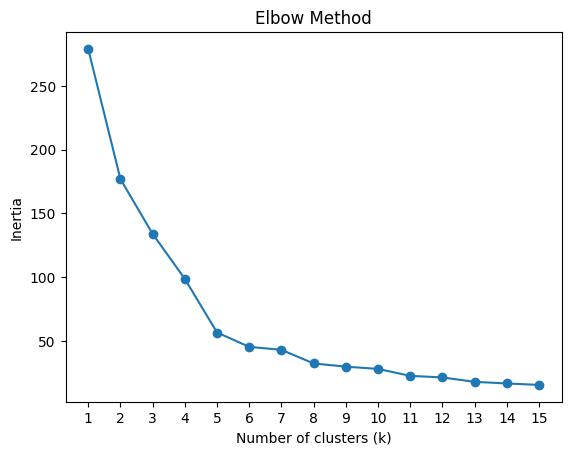

[279.00000000000006, 176.9733968871539, 133.97095804786815, 98.65887202515705, 56.598996626565096, 45.34218509887986, 43.01028522188079, 32.31563734207697, 29.81274733526639, 28.03664437830995, 22.600387790225753, 21.365341951197323, 17.90534605169987, 16.63766270853415, 15.491999156788554]


In [70]:
inertias = []
k_range = range(1, 16)
KMeans(n_clusters=k, random_state=42, n_init=10)
for k in k_range:
 
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    

plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()
print(inertias)

In [71]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_encoded["cluster"] = kmeans.labels_
print(df_encoded["cluster"].value_counts().sort_index())

cluster
0    12
1    21
2     7
3     2
4    15
5    10
6     2
7     8
8     4
9    12
Name: count, dtype: int64


In [72]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_encoded["cluster"] = kmeans.labels_
print(df_encoded["cluster"].value_counts().sort_index())

cluster
0    24
1     9
2    19
3    22
4    11
5     8
Name: count, dtype: int64


In [73]:
df_encoded.groupby("cluster")[feature_cols].mean().round(2)

,sentiment_score,emotional_affinity_score,confidence_score
cluster,,,
0,0.92,90.17,0.87
1,0.51,81.33,0.43
2,0.72,83.11,0.63
3,0.88,51.86,0.64
4,0.19,83.91,0.73
5,0.40,42.12,0.35


In [74]:
df_encoded.groupby("cluster")["source"].value_counts()

cluster  source   
0        reddit       20
         bcg           2
         wasserman     1
         mckinsey      1
1        reddit        7
         deloitte      1
         wasserman     1
2        reddit       12
         deloitte      2
         nielsen       2
         bcg           1
         mckinsey      1
         wasserman     1
3        reddit       21
         nielsen       1
4        reddit       11
5        reddit        7
         mckinsey      1
Name: count, dtype: int64

In [75]:
print(df_filtered["behavioral_pathway"].value_counts())
print(df_filtered["priority_signal"].value_counts())

behavioral_pathway
none                   84
churn_risk              4
purchase_intent         3
identity_attachment     1
community_influence     1
Name: count, dtype: int64
priority_signal
none                    66
loyalty_stress          24
identity_anchor          2
cross_sport_superfan     1
Name: count, dtype: int64


[0.56188851 0.32504827]
Total variance explained: 88.69%


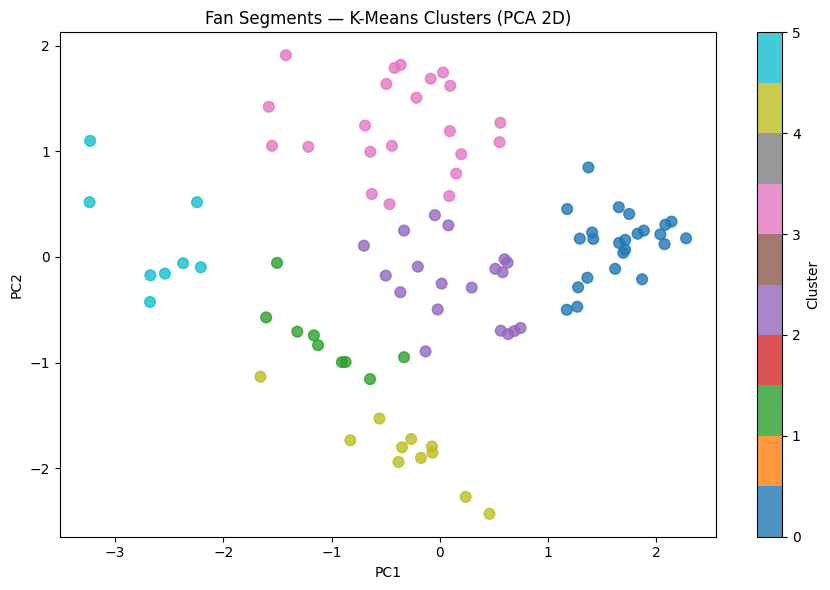

In [79]:
# some pca for 2d visualization

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df_encoded["cluster"], cmap="tab10", s=60, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fan Segments — K-Means Clusters (PCA 2D)")
plt.tight_layout()
plt.show()

In [81]:
df_encoded.groupby("cluster")[feature_cols].mean().round(2)


,sentiment_score,emotional_affinity_score,confidence_score
cluster,,,
0,0.92,90.17,0.87
1,0.51,81.33,0.43
2,0.72,83.11,0.63
3,0.88,51.86,0.64
4,0.19,83.91,0.73
5,0.40,42.12,0.35


In [82]:
df_encoded.groupby("cluster")["source"].value_counts()

cluster  source   
0        reddit       20
         bcg           2
         wasserman     1
         mckinsey      1
1        reddit        7
         deloitte      1
         wasserman     1
2        reddit       12
         deloitte      2
         nielsen       2
         bcg           1
         mckinsey      1
         wasserman     1
3        reddit       21
         nielsen       1
4        reddit       11
5        reddit        7
         mckinsey      1
Name: count, dtype: int64

In [83]:
cluster_labels = {
    0: "Superfan",
    1: "Emotionally Invested, Weak Signal",
    2: "Core Engaged Fan",
    3: "Casual Enthusiast",
    4: "Frustrated Loyalist",
    5: "Passive / Disengaged"
}

df_encoded["segment"] = df_encoded["cluster"].map(cluster_labels)
print(df_encoded["segment"].value_counts())

segment
Superfan                             24
Casual Enthusiast                    22
Core Engaged Fan                     19
Frustrated Loyalist                  11
Emotionally Invested, Weak Signal     9
Passive / Disengaged                  8
Name: count, dtype: int64


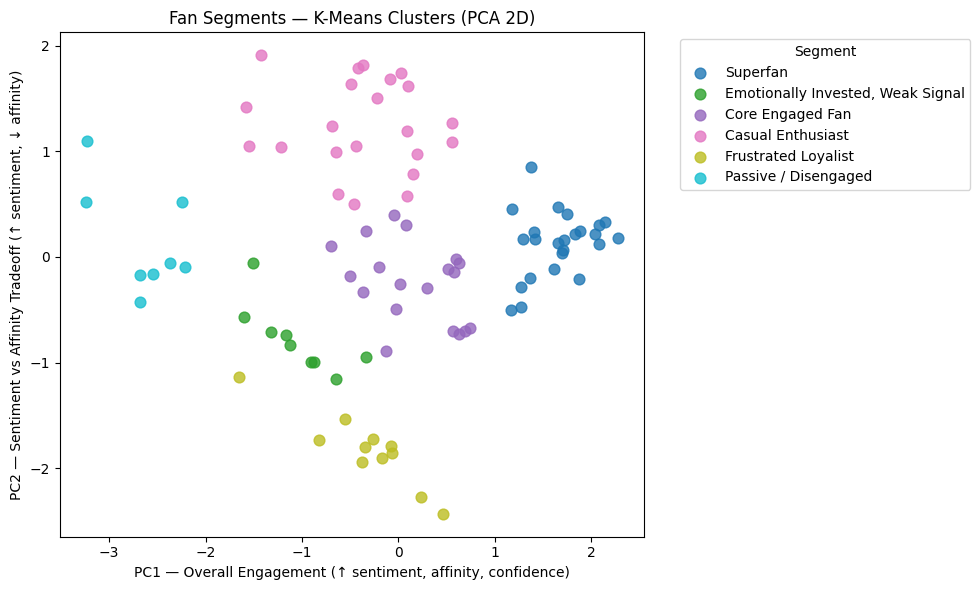

In [92]:

fig, ax = plt.subplots(figsize=(10, 6))

cluster_order = sorted(df_encoded["cluster"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_order)))

for cluster_id, color in zip(cluster_order, colors):
    mask = df_encoded["cluster"] == cluster_id
    label = cluster_labels[cluster_id]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=[color], label=label, s=60, alpha=0.8)

ax.set_xlabel("PC1 — Overall Engagement (↑ sentiment, affinity, confidence)")
ax.set_ylabel("PC2 — Sentiment vs Affinity Tradeoff (↑ sentiment, ↓ affinity)")
ax.set_title("Fan Segments — K-Means Clusters (PCA 2D)")
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [90]:
export_cols = [
    "record_id",
    "source",
    "sports",
    "sentiment_encoded",
    "sentiment_score",
    "emotional_affinity_score",
    "confidence_score",
    "cluster",
    "segment"
]

df_export = df_encoded[export_cols].copy()

df_export.to_json("fan_segments.json", orient="records", indent=2)
print(f"Exported {len(df_export)} rows")

Exported 93 rows


In [91]:
pca.components_

array([[ 0.4521389 ,  0.55211468,  0.70052823],
       [ 0.77862364, -0.62743979, -0.00803296]])